In [1]:
import numpy as np
import pandas as pd
import pickle
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df=pd.read_csv('/content/fake_news_dataset.csv')
df

,id,title,author,text,state,date_published,source,category,sentiment_score,word_count,...,num_shares,num_comments,political_bias,fact_check_rating,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score,label
0,1,Breaking News 1,Jane Smith,This is the content of article 1. It contains ...,Tennessee,30-11-2021,The Onion,Entertainment,-0.22,1302,...,47305,450,Center,FALSE,1,76,6,0.84,53.35,Fake
1,2,Breaking News 2,Emily Davis,This is the content of article 2. It contains ...,Wisconsin,02-09-2021,The Guardian,Technology,0.92,322,...,39804,530,Left,Mixed,1,1,5,0.85,28.28,Fake
2,3,Breaking News 3,John Doe,This is the content of article 3. It contains ...,Missouri,13-04-2021,New York Times,Sports,0.25,228,...,45860,763,Center,Mixed,0,57,1,0.72,0.38,Fake
3,4,Breaking News 4,Alex Johnson,This is the content of article 4. It contains ...,North Carolina,08-03-2020,CNN,Sports,0.94,155,...,34222,945,Center,TRUE,1,18,10,0.92,32.20,Fake
4,5,Breaking News 5,Emily Davis,This is the content of article 5. It contains ...,California,23-03-2022,Daily Mail,Technology,-0.01,962,...,35934,433,Right,Mixed,0,95,6,0.66,77.70,Real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,Breaking News 3996,John Doe,This is the content of article 3996. It contai...,Ohio,25-04-2020,InfoWars,Technology,0.91,1227,...,38880,697,Right,Mixed,0,29,10,0.22,95.46,Fake
3996,3997,Breaking News 3997,Alex Johnson,This is the content of article 3997. It contai...,Washington,09-01-2022,CNN,Sports,-0.57,1296,...,3650,925,Left,FALSE,1,53,3,0.42,16.54,Fake
3997,3998,Breaking News 3998,Alex Johnson,This is the content of article 3998. It contai...,California,03-03-2023,Breitbart,Entertainment,-0.17,522,...,35391,577,Left,FALSE,0,22,9,0.50,28.51,Fake
3998,3999,Breaking News 3999,John Doe,This is the content of article 3999. It contai...,Illinois,13-04-2021,New York Times,Health,-0.88,169,...,40424,201,Left,FALSE,1,3,6,0.17,71.16,Real


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4000 non-null   int64  
 1   title              4000 non-null   object 
 2   author             4000 non-null   object 
 3   text               4000 non-null   object 
 4   state              4000 non-null   object 
 5   date_published     4000 non-null   object 
 6   source             4000 non-null   object 
 7   category           4000 non-null   object 
 8   sentiment_score    4000 non-null   float64
 9   word_count         4000 non-null   int64  
 10  char_count         4000 non-null   int64  
 11  has_images         4000 non-null   int64  
 12  has_videos         4000 non-null   int64  
 13  readability_score  4000 non-null   float64
 14  num_shares         4000 non-null   int64  
 15  num_comments       4000 non-null   int64  
 16  political_bias     4000 

In [4]:
df.isnull()

,id,title,author,text,state,date_published,source,category,sentiment_score,word_count,...,num_shares,num_comments,political_bias,fact_check_rating,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.size

96000

In [7]:
df.shape

(4000, 24)

In [8]:
df.columns

Index(['id', 'title', 'author', 'text', 'state', 'date_published', 'source',
       'category', 'sentiment_score', 'word_count', 'char_count', 'has_images',
       'has_videos', 'readability_score', 'num_shares', 'num_comments',
       'political_bias', 'fact_check_rating', 'is_satirical', 'trust_score',
       'source_reputation', 'clickbait_score', 'plagiarism_score', 'label'],
      dtype='object')

In [9]:
df.dtypes

,0
id,int64
title,object
author,object
text,object
state,object
date_published,object
source,object
category,object
sentiment_score,float64
word_count,int64


In [10]:
x=df.iloc[ : ,0:-1]
x.shape

(4000, 23)

In [11]:
y=df.iloc[ : ,-1]
y.shape

(4000,)

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=51)

In [13]:
x_train.shape

(3200, 23)

In [14]:
x_test.shape

(800, 23)

In [15]:
y_test.shape

(800,)

In [16]:
y_train.shape

(3200,)

In [17]:
from numpy.random.mtrand import random
models={
    "LR":LogisticRegression(),
    "SVC1":SVC(kernel="rbf"),
    "SVC2":SVC(kernel="poly"),
    "TREE":DecisionTreeClassifier(criterion="gini"),
    "RF":RandomForestClassifier(n_estimators=200,random_state=52),
    "RF1":RandomForestClassifier(n_estimators=100,random_state=42),
    "KNN":KNeighborsClassifier(n_neighbors=3),
    "NB":GaussianNB()
}
r={}

In [18]:
non_numeric_cols = ['title', 'author', 'text', 'state', 'date_published', 'source', 'category', 'political_bias', 'fact_check_rating']
x_train_processed = x_train.drop(columns=non_numeric_cols)
x_test_processed = x_test.drop(columns=non_numeric_cols)

for name,model in models.items():
  pipe=Pipeline([
      ("sc",MinMaxScaler()),
      ("model",model)
  ])
  pipe.fit(x_train_processed,y_train)
  y_pred=pipe.predict(x_test_processed)
  score=accuracy_score(y_test,y_pred)
  c_m=confusion_matrix(y_test,y_pred)
  c_r=classification_report(y_test,y_pred)

  r[name]={
      "pipe":pipe,
      "y_pred":y_pred,
      "score":score,
      "c_m":c_m,
      "c_r":c_r
  }
  print(name)
  print("----------------------------------------------------------------------------------")
  print(y_pred)
  print("----------------------------------------------------------------------------------")
  print(score)
  print("----------------------------------------------------------------------------------")
  print(c_m)
  print("----------------------------------------------------------------------------------")
  print(c_r)
  print("----------------------------------------------------------------------------------")

LR
----------------------------------------------------------------------------------
['Real' 'Real' 'Fake' 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Fake' 'Real'
 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Fake' 'Fake'
 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Real' 'Real'
 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Fake' 'Fake'
 'Fake' 'Fake' 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake'
 'Fake' 'Real' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Real' 'Real' 'Real'
 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Real' 'Real'
 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Real' 'Real'
 'Fake' 'Fake' 'Fake' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Real' 'Fake'
 'Real' 'Real' 'Real' 'Real' 'Fake' 'Fake' 'Real' 'Real' 'Real' 'Real'
 'Real' 'Real' 'Real' 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Real' 'Fake'
 'Real' 'Real' 'Real' 'Real' 'Real' 'Real' 'Real' 'Fake' 'Fake' 'Fake'
 'Fake' 'Fake' 'Fake' 'Real' 'Fake' 'Fake' 'Real' 'Real' 'Fake

In [19]:
best_pipe_name=max(r,key=lambda x:r[x]["score"])
best_model=r[best_pipe_name]["pipe"]
print(f"the best and most authenticate model name is {best_pipe_name}")

the best and most authenticate model name is TREE


In [20]:
with open("SVC.pkl","wb") as f:
  pickle.dump(best_model,f)

In [21]:
joblib.dump(best_model,"SVC.joblib")

['SVC.joblib']

In [22]:
with open("SVC.pkl","rb") as f:
  model=pickle.load(f)

In [23]:
model

Pipeline(steps=[('sc', MinMaxScaler()), ('model', DecisionTreeClassifier())])

In [24]:
import pickle
import numpy as np
import pandas as pd # Import pandas for DataFrame manipulation

# Load the model
with open("/content/SVC.pkl", "rb") as file:
    model = pickle.load(file)

# Define non_numeric_cols as they were defined during training
non_numeric_cols = ['title', 'author', 'text', 'state', 'date_published', 'source', 'category', 'political_bias', 'fact_check_rating']

# Get the list of numerical columns used for training
# Exclude the 'label' column as it's the target variable
numeric_cols_for_prediction = [col for col in df.columns if col not in non_numeric_cols and col != 'label']

# Select a sample row from the original DataFrame for prediction
# Using the first row (index 0) as an example
sample_input_df = df.iloc[[0]][numeric_cols_for_prediction]

# Make prediction
prediction = model.predict(sample_input_df)

print("Prediction:", prediction)


Prediction: ['Fake']


1. How many Fake vs Real news articles are in the dataset?

#Plot

Bar Chart

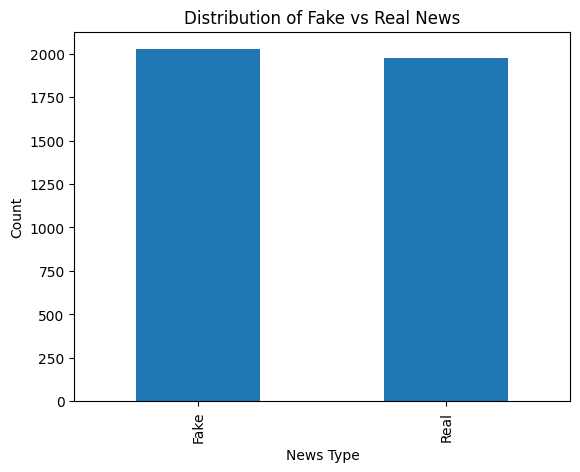

In [25]:
import matplotlib.pyplot as plt
df = pd.read_csv("/content/fake_news_dataset.csv")

label_counts = df['label'].value_counts()

plt.figure()
label_counts.plot(kind='bar')
plt.xlabel("News Type")
plt.ylabel("Count")
plt.title("Distribution of Fake vs Real News")
plt.show()

#Interpretation

If Fake news count is higher, it indicates the dataset contains more misleading content. Balanced datasets are better for training ML models.

2. What is the distribution of sentiment scores in articles?

#Plot

Histogram

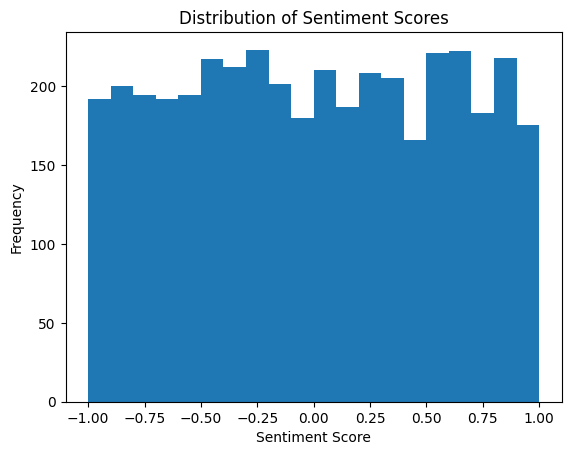

In [26]:
plt.figure()
plt.hist(df['sentiment_score'], bins=20)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of Sentiment Scores")
plt.show()

#Interpretation

If most values are near 0, the articles are neutral. Positive values indicate positive sentiment and negative values indicate negative sentiment.

3. Do Fake and Real news differ in average word count?
#Plot

Bar Chart

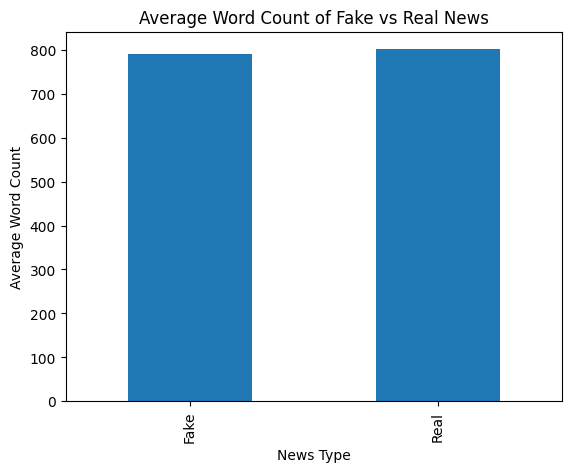

In [27]:
avg_words = df.groupby('label')['word_count'].mean()

plt.figure()
avg_words.plot(kind='bar')
plt.xlabel("News Type")
plt.ylabel("Average Word Count")
plt.title("Average Word Count of Fake vs Real News")
plt.show()

#Interpretation

If fake news has lower word counts, it suggests fake articles may be shorter and less detailed.

4. How does clickbait score relate to news type?
#Plot

Box Plot

<Figure size 640x480 with 0 Axes>

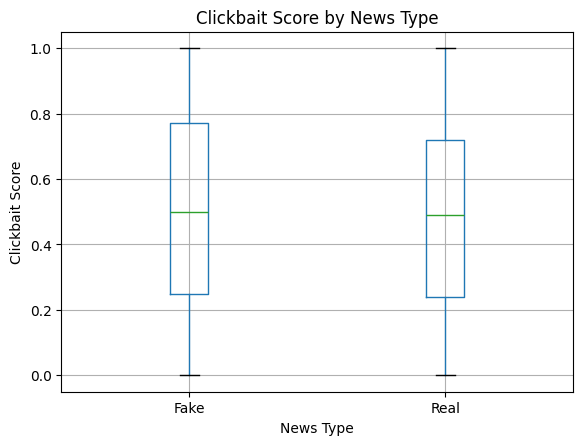

In [28]:
plt.figure()
df.boxplot(column='clickbait_score', by='label')
plt.xlabel("News Type")
plt.ylabel("Clickbait Score")
plt.title("Clickbait Score by News Type")
plt.suptitle("")
plt.show()

#Interpretation

Higher clickbait scores for Fake news indicate that misleading headlines are commonly used to attract readers.

5. What is the distribution of trust scores?
#Plot

Histogram

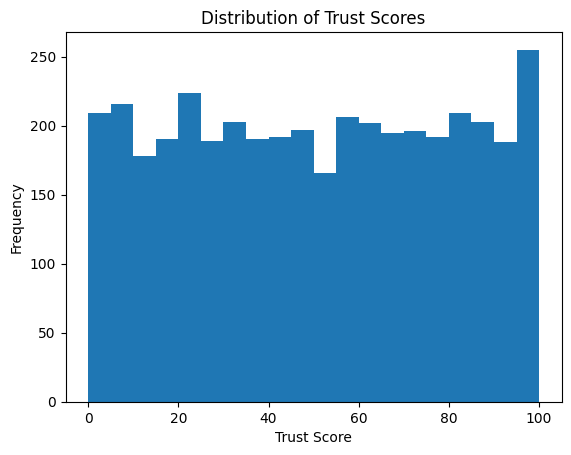

In [29]:
plt.figure()
plt.hist(df['trust_score'], bins=20)
plt.xlabel("Trust Score")
plt.ylabel("Frequency")
plt.title("Distribution of Trust Scores")
plt.show()

#Interpretation

Higher trust scores indicate reliable content. Fake news usually shows lower trust scores.

6. Which category has the most news articles?
#Plot

Bar Chart

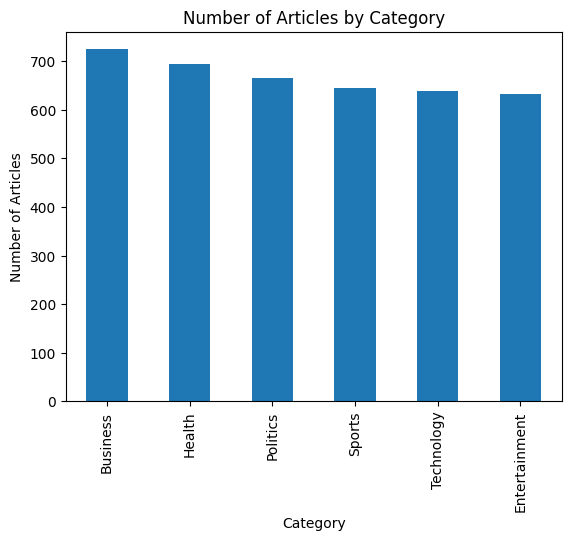

In [30]:
category_counts = df['category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.title("Number of Articles by Category")
plt.show()

#Interpretation

This shows which topics (politics, health, technology, etc.) dominate the dataset.

7. Relationship between shares and comments
#Plot

Scatter Plot

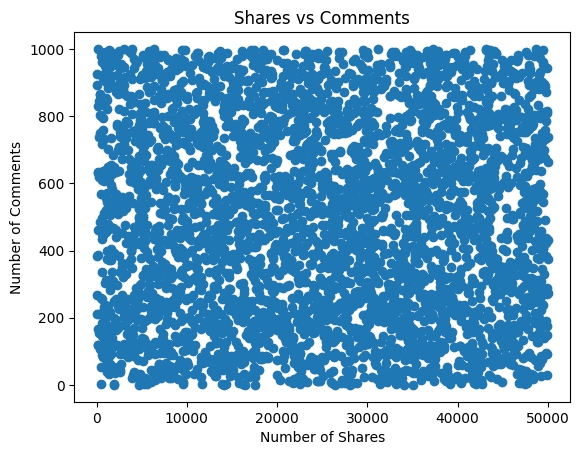

In [31]:
plt.figure()
plt.scatter(df['num_shares'], df['num_comments'])
plt.xlabel("Number of Shares")
plt.ylabel("Number of Comments")
plt.title("Shares vs Comments")
plt.show()

8. Do satirical articles have different trust scores?
#Plot

Bar Chart

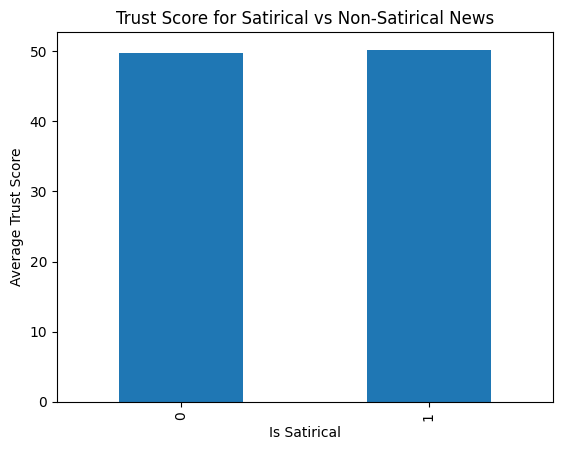

In [32]:
satirical_trust = df.groupby('is_satirical')['trust_score'].mean()

plt.figure()
satirical_trust.plot(kind='bar')
plt.xlabel("Is Satirical")
plt.ylabel("Average Trust Score")
plt.title("Trust Score for Satirical vs Non-Satirical News")
plt.show()

#Interpretation

Satirical articles may have lower trust scores because they are intended as humor rather than factual reporting.

9. Does source reputation affect trust score?
#Plot

Scatter Plot

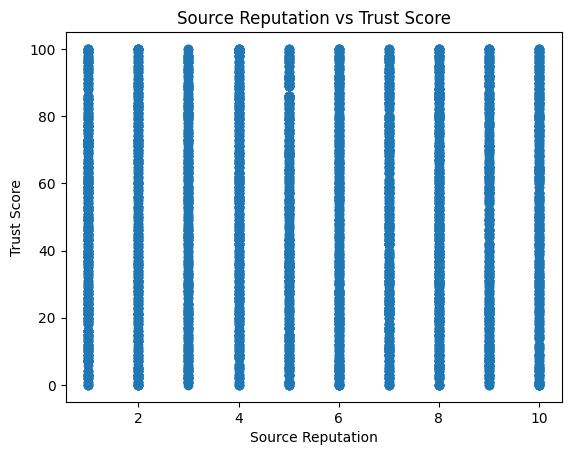

In [33]:
plt.figure()
plt.scatter(df['source_reputation'], df['trust_score'])
plt.xlabel("Source Reputation")
plt.ylabel("Trust Score")
plt.title("Source Reputation vs Trust Score")
plt.show()

#Interpretation

A positive trend suggests reputable sources tend to publish more trustworthy content.

10. Average number of shares for Fake vs Real news
#Plot

Bar Chart

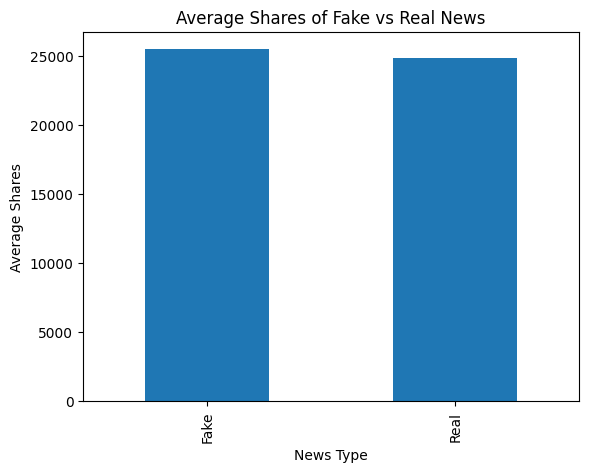

In [34]:
avg_shares = df.groupby('label')['num_shares'].mean()

plt.figure()
avg_shares.plot(kind='bar')
plt.xlabel("News Type")
plt.ylabel("Average Shares")
plt.title("Average Shares of Fake vs Real News")
plt.show()

#Interpretation

If fake news has higher shares, it indicates misleading content spreads faster on social media.